# AD MEG Classification: Evaluation Notebook

Compares hand-crafted baseline features vs BrainOmni frozen features across multiple classifiers and evaluation strategies.

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    print('XGBoost not installed. Run: pip install xgboost')
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    print('LightGBM not installed. Run: pip install lightgbm')
    HAS_LGBM = False

DATA_DIR = '/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/data'

baseline_features = np.load(f'{DATA_DIR}/baseline_features.npy')
tiny_features     = np.load(f'{DATA_DIR}/brainomni_features_tiny.npy')
base_features     = np.load(f'{DATA_DIR}/brainomni_features_base.npy')
labels            = np.load(f'{DATA_DIR}/labels.npy')

print('Baseline features:', baseline_features.shape)
print('BrainOmni-tiny:  ', tiny_features.shape)
print('BrainOmni-base:  ', base_features.shape)
print('Labels:          ', labels.shape)
print('Controls:', (labels==0).sum(), '| AD:', (labels==1).sum())

Baseline features: (148, 6)
BrainOmni-tiny:   (148, 8192)
BrainOmni-base:   (148, 8192)
Labels:           (148,)
Controls: 70 | AD: 78


## Classifiers

In [46]:
classifiers = {
    'Logistic Regression': lambda: LogisticRegression(max_iter=1000),
    'Gradient Boosting':   lambda: GradientBoostingClassifier(n_estimators=100, random_state=123),
    'Random Forest':       lambda: RandomForestClassifier(n_estimators=100, random_state=123),
    **({'LightGBM': lambda: LGBMClassifier(n_estimators=100, random_state=123, verbose=-1)} if HAS_LGBM else {}),
    **({'XGBoost': lambda: XGBClassifier(n_estimators=100, random_state=123, eval_metric='logloss')} if HAS_XGB else {}),
    'KNN':             lambda: KNeighborsClassifier(n_neighbors=5)
}

# needs_pca: baseline has 6 features (no PCA needed), BrainOmni has 4096/8192
feature_sets = {
    'Baseline':       (baseline_features, False),
    'BrainOmni-tiny': (tiny_features,     True),
    'BrainOmni-base': (base_features,     True),
}

PCA_N = 50

print('Classifiers:', list(classifiers.keys()))
print('Feature sets:', list(feature_sets.keys()))

Classifiers: ['Logistic Regression', 'Gradient Boosting', 'Random Forest', 'LightGBM', 'XGBoost', 'KNN']
Feature sets: ['Baseline', 'BrainOmni-tiny', 'BrainOmni-base']


## 5-Fold Cross Validation

In [47]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
results_5fold = {}

for clf_name, clf_fn in classifiers.items():
    for feat_name, (features, needs_pca) in feature_sets.items():
        y_pred_all = []
        y_true_all = []

        for train_idx, test_idx in cv.split(features, labels):
            if needs_pca:
                pca = PCA(n_components=PCA_N)
                X_train = pca.fit_transform(features[train_idx])
                X_test  = pca.transform(features[test_idx])
            else:
                X_train = features[train_idx]
                X_test  = features[test_idx]

            clf = clf_fn()
            clf.fit(X_train, labels[train_idx])
            y_pred_all.extend(clf.predict(X_test))
            y_true_all.extend(labels[test_idx])

        acc = accuracy_score(y_true_all, y_pred_all)
        results_5fold[f'{clf_name} | {feat_name}'] = {
            'acc': acc, 'y_true': y_true_all, 'y_pred': y_pred_all
        }
        print(f'{clf_name:22s} | {feat_name:15s} | Accuracy: {acc:.3f}')

Logistic Regression    | Baseline        | Accuracy: 0.872
Logistic Regression    | BrainOmni-tiny  | Accuracy: 0.831
Logistic Regression    | BrainOmni-base  | Accuracy: 0.831
Gradient Boosting      | Baseline        | Accuracy: 0.824
Gradient Boosting      | BrainOmni-tiny  | Accuracy: 0.811
Gradient Boosting      | BrainOmni-base  | Accuracy: 0.804
Random Forest          | Baseline        | Accuracy: 0.845
Random Forest          | BrainOmni-tiny  | Accuracy: 0.818
Random Forest          | BrainOmni-base  | Accuracy: 0.777


/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifi

LightGBM               | Baseline        | Accuracy: 0.838


/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifi

LightGBM               | BrainOmni-tiny  | Accuracy: 0.791


/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM               | BrainOmni-base  | Accuracy: 0.750
XGBoost                | Baseline        | Accuracy: 0.791
XGBoost                | BrainOmni-tiny  | Accuracy: 0.797
XGBoost                | BrainOmni-base  | Accuracy: 0.804
KNN                    | Baseline        | Accuracy: 0.811
KNN                    | BrainOmni-tiny  | Accuracy: 0.777
KNN                    | BrainOmni-base  | Accuracy: 0.777


## 80/10/10 Split

Fixed train/val/test split. Required for fine-tuning. (Might be more noisy than 5-fold CV due to small test set,15 subjects).

In [48]:
idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.2, stratify=labels, random_state=123)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, stratify=labels[temp_idx], random_state=123)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

results_801010 = {}

for clf_name, clf_fn in classifiers.items():
    for feat_name, (features, needs_pca) in feature_sets.items():
        if needs_pca:
            pca = PCA(n_components=PCA_N)
            X_train = pca.fit_transform(features[train_idx])
            X_test  = pca.transform(features[test_idx])
        else:
            X_train = features[train_idx]
            X_test  = features[test_idx]

        clf = clf_fn()
        clf.fit(X_train, labels[train_idx])
        acc = accuracy_score(labels[test_idx], clf.predict(X_test))
        results_801010[f'{clf_name} | {feat_name}'] = acc
        print(f'{clf_name:22s} | {feat_name:15s} | Accuracy: {acc:.3f}')

Train: 118 | Val: 15 | Test: 15
Logistic Regression    | Baseline        | Accuracy: 0.800
Logistic Regression    | BrainOmni-tiny  | Accuracy: 0.867
Logistic Regression    | BrainOmni-base  | Accuracy: 0.800
Gradient Boosting      | Baseline        | Accuracy: 0.600
Gradient Boosting      | BrainOmni-tiny  | Accuracy: 0.733
Gradient Boosting      | BrainOmni-base  | Accuracy: 0.800
Random Forest          | Baseline        | Accuracy: 0.600
Random Forest          | BrainOmni-tiny  | Accuracy: 0.800
Random Forest          | BrainOmni-base  | Accuracy: 0.733


/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM               | Baseline        | Accuracy: 0.533
LightGBM               | BrainOmni-tiny  | Accuracy: 0.733
LightGBM               | BrainOmni-base  | Accuracy: 0.800
XGBoost                | Baseline        | Accuracy: 0.467
XGBoost                | BrainOmni-tiny  | Accuracy: 0.733
XGBoost                | BrainOmni-base  | Accuracy: 0.733
KNN                    | Baseline        | Accuracy: 0.600
KNN                    | BrainOmni-tiny  | Accuracy: 0.800
KNN                    | BrainOmni-base  | Accuracy: 0.800


## Results Summary

In [49]:
rows = []
for key, val in results_5fold.items():
    clf_name, feat_name = key.split(' | ')
    rows.append({'Classifier': clf_name, 'Features': feat_name,
                 '5-Fold CV': round(val['acc'], 3),
                 '80/10/10':  round(results_801010.get(key, float('nan')), 3)})

df_results = pd.DataFrame(rows)
pivot = df_results.pivot_table(index='Classifier', columns='Features',
                               values=['5-Fold CV', '80/10/10'])
print(pivot.to_string())

save_path = '/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/metrics/accuracy_summary.csv'
pivot.to_csv(save_path)
print(f'\nSaved to {save_path}')

                    5-Fold CV                               80/10/10                              
Features             Baseline BrainOmni-base BrainOmni-tiny Baseline BrainOmni-base BrainOmni-tiny
Classifier                                                                                        
Gradient Boosting       0.824          0.804          0.811    0.600          0.800          0.733
KNN                     0.811          0.777          0.777    0.600          0.800          0.800
LightGBM                0.838          0.750          0.791    0.533          0.800          0.733
Logistic Regression     0.872          0.831          0.831    0.800          0.800          0.867
Random Forest           0.845          0.777          0.818    0.600          0.733          0.800
XGBoost                 0.791          0.804          0.797    0.467          0.733          0.733

Saved to /Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/metrics/accuracy_summary.csv


## PCA Component Sweep

How does accuracy change with the number of PCA components (1 to 50)?

/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/brainomni/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifi

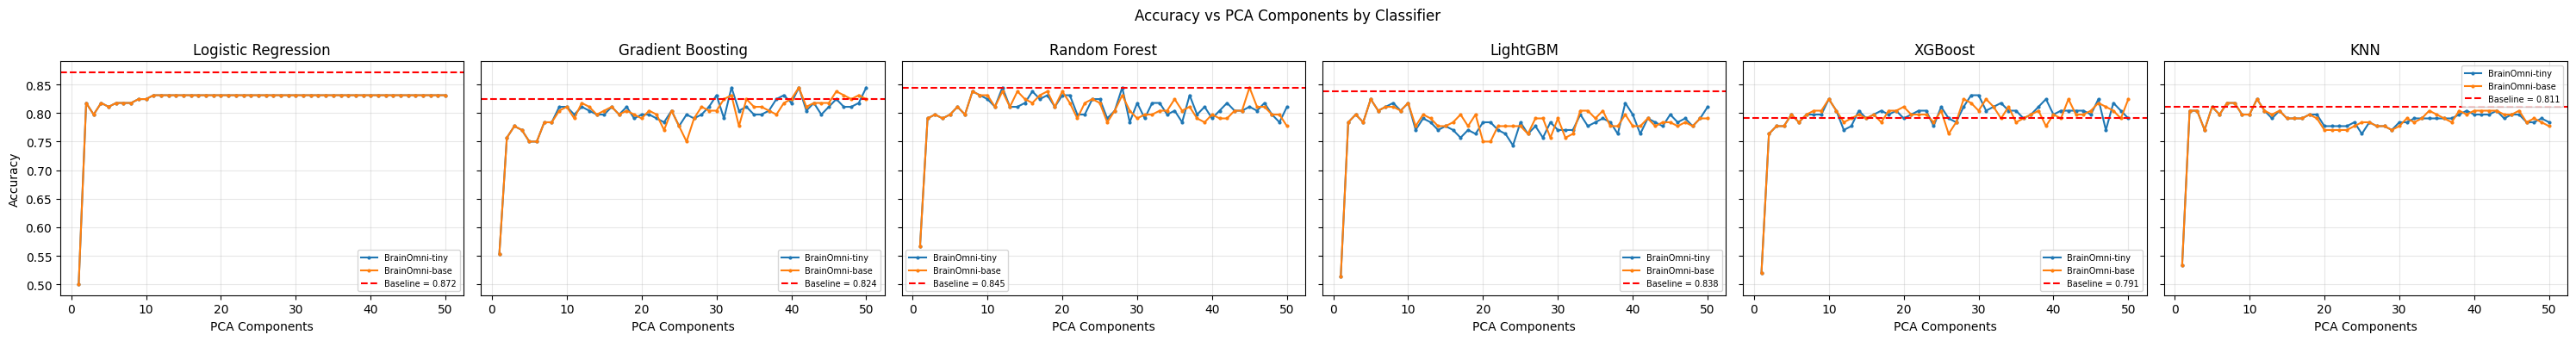

In [50]:
pca_range  = range(1, 51)
pca_results = {clf_name: {feat_name: [] for feat_name in ['BrainOmni-tiny', 'BrainOmni-base']}
               for clf_name in classifiers}

for n in pca_range:
    for clf_name, clf_fn in classifiers.items():
        for feat_name, features in [('BrainOmni-tiny', tiny_features), ('BrainOmni-base', base_features)]:
            y_pred_all, y_true_all = [], []
            for train_idx, test_idx in cv.split(features, labels):
                pca = PCA(n_components=n)
                X_train = pca.fit_transform(features[train_idx])
                X_test  = pca.transform(features[test_idx])
                clf = clf_fn()
                clf.fit(X_train, labels[train_idx])
                y_pred_all.extend(clf.predict(X_test))
                y_true_all.extend(labels[test_idx])
            pca_results[clf_name][feat_name].append(accuracy_score(y_true_all, y_pred_all))

fig, axes = plt.subplots(1, len(classifiers), figsize=(5*len(classifiers), 4), sharey=True)
if len(classifiers) == 1:
    axes = [axes]

for ax, (clf_name, feat_accs) in zip(axes, pca_results.items()):
    for feat_name, accs in feat_accs.items():
        ax.plot(pca_range, accs, label=feat_name, marker='o', markersize=2)
    baseline_acc = results_5fold[f'{clf_name} | Baseline']['acc']
    ax.axhline(y=baseline_acc, color='red', linestyle='--', label=f'Baseline = {baseline_acc:.3f}')
    ax.set_title(clf_name)
    ax.set_xlabel('PCA Components')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Accuracy')
plt.suptitle('Accuracy vs PCA Components by Classifier')
plt.tight_layout()
plt.savefig('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/figures/pca_sweep.png', dpi=150)
plt.show()

## Visualizations

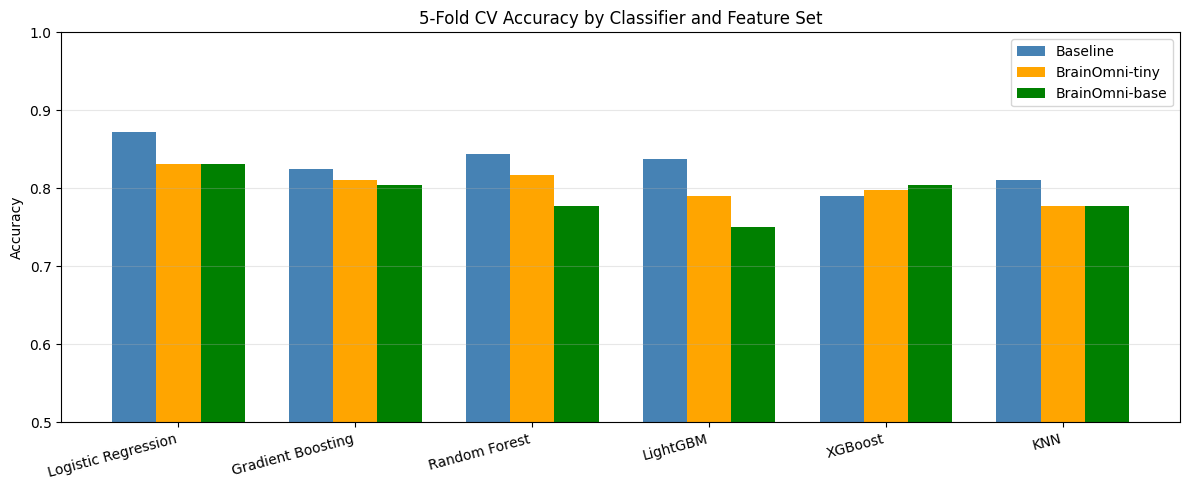

In [51]:
# Bar chart: 5-fold CV accuracy for all classifiers x feature sets
clf_names  = list(classifiers.keys())
feat_names = list(feature_sets.keys())
x = np.arange(len(clf_names))
width = 0.25
colors = ['steelblue', 'orange', 'green']

fig, ax = plt.subplots(figsize=(12, 5))
for i, feat_name in enumerate(feat_names):
    accs = [results_5fold[f'{clf} | {feat_name}']['acc'] for clf in clf_names]
    ax.bar(x + i*width, accs, width, label=feat_name, color=colors[i])

ax.set_ylabel('Accuracy')
ax.set_title('5-Fold CV Accuracy by Classifier and Feature Set')
ax.set_xticks(x + width)
ax.set_xticklabels(clf_names, rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/figures/accuracy_bar.png', dpi=150)
plt.show()

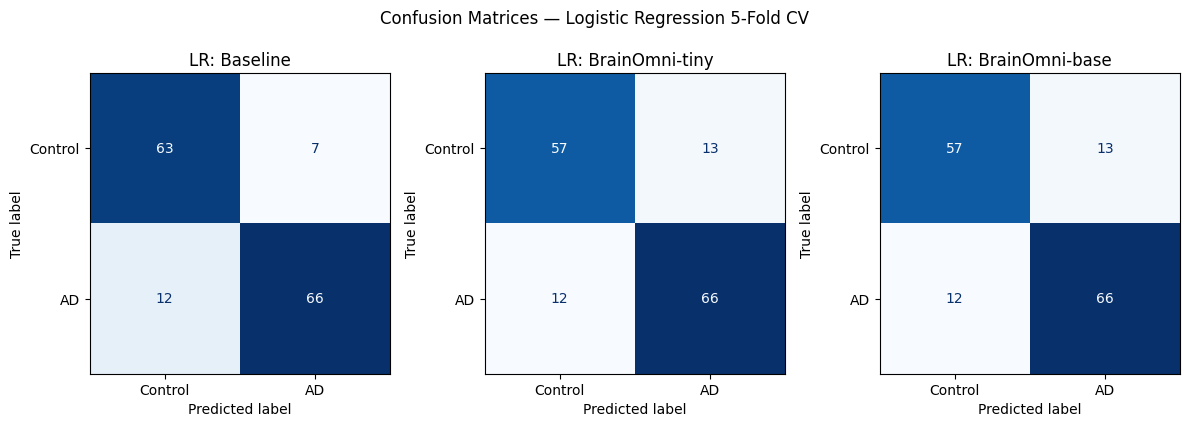

In [52]:
# Confusion matrices for LR 5-fold (one per feature set)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, feat_name in zip(axes, feat_names):
    key = f'Logistic Regression | {feat_name}'
    ConfusionMatrixDisplay.from_predictions(
        results_5fold[key]['y_true'],
        results_5fold[key]['y_pred'],
        display_labels=['Control', 'AD'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'LR: {feat_name}')

plt.suptitle('Confusion Matrices — Logistic Regression 5-Fold CV', y=1.02)
plt.tight_layout()
plt.savefig('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

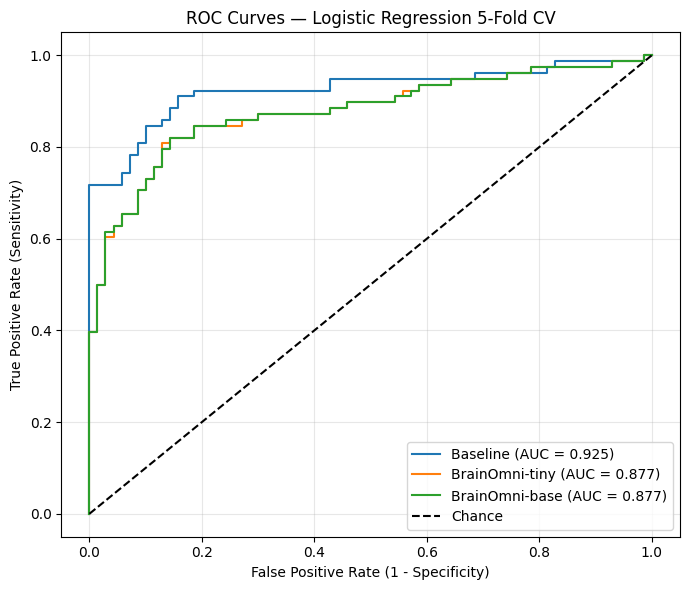

In [53]:
# ROC curves for LR 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
fig, ax = plt.subplots(figsize=(7, 6))

for feat_name, (features, needs_pca) in feature_sets.items():
    probas, y_true_roc = [], []
    for train_idx, test_idx in cv.split(features, labels):
        if needs_pca:
            pca = PCA(n_components=PCA_N)
            X_train = pca.fit_transform(features[train_idx])
            X_test  = pca.transform(features[test_idx])
        else:
            X_train = features[train_idx]
            X_test  = features[test_idx]
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, labels[train_idx])
        probas.extend(clf.predict_proba(X_test)[:, 1])
        y_true_roc.extend(labels[test_idx])

    fpr, tpr, _ = roc_curve(y_true_roc, probas)
    ax.plot(fpr, tpr, label=f'{feat_name} (AUC = {auc(fpr, tpr):.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Chance')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — Logistic Regression 5-Fold CV')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/figures/roc_curves.png', dpi=150)
plt.show()

In [54]:
# Regional MEG features — placeholder
# Uncomment and run when ready to test

# import pandas as pd
#
# regional_files = [
#     f'/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/data/eLife91044_processeddata_regionalmegmetric_{i}.xlsx'
#     for i in range(1, 7)
# ]
#
# dfs = [pd.read_excel(f).drop(columns=['ID']) for f in regional_files]
# regional_features = np.concatenate([df.values for df in dfs], axis=1)  # (148, 564)
# print('Regional features shape:', regional_features.shape)
#
# # Add to feature_sets and rerun evaluation
# feature_sets['Regional MEG'] = (regional_features, True)